<a href="https://colab.research.google.com/github/InfiniteLobster/CDA-case1/blob/main/case_workspace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost joblib -q

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import libraries
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_style("whitegrid")

In [4]:
import warnings
warnings.filterwarnings('ignore')

# Set up styling for matplotlib (for report)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [5]:
# Load datasets
train_df = pd.read_csv("/content/drive/MyDrive/case-data/case1Data.csv")
xnew_df = pd.read_csv("/content/drive/MyDrive/case-data/case1Data_Xnew.csv")

print("Training data shape:", train_df.shape)
print("New data shape:", xnew_df.shape)

Training data shape: (100, 101)
New data shape: (1000, 100)


In [6]:
# Split features and target
y_train = train_df.iloc[:,0]
X_train = train_df.iloc[:,1:]
X_new = xnew_df

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print(X_train.head())
print(y_train.head())

X_train shape: (100, 100)
y_train shape: (100,)
       x_01       x_02      x_03       x_04       x_05      x_06       x_07  \
0  6.359019 -13.367120 -2.483750  -6.641891  11.733539       NaN -17.085361   
1  3.873664  -8.470389 -3.055012        NaN  11.420983  1.822330 -13.694100   
2  5.275824 -12.070531 -1.366168  -4.819100  10.721527 -5.125992 -17.476865   
3  4.430110  -4.467975 -0.730736 -10.047104  11.498539 -2.870260 -14.033012   
4  3.116458  -8.518713 -6.796050        NaN   7.646285 -3.118309 -13.102567   

        x_08       x_09       x_10  ...       x_91       x_92      x_93  \
0  22.194764  16.827888 -10.367142  ... -10.200888   3.980048 -4.433274   
1  22.738654  20.307503  -2.859097  ...  -9.740207        NaN -2.629314   
2        NaN  15.963889  -3.257940  ... -14.501970  10.054005       NaN   
3  18.225190  10.409488  -5.616061  ... -11.086963   2.019726 -8.531959   
4  22.801217  16.680208  -3.357765  ...  -9.117422   6.627601 -2.805531   

       x_94       x_95  C_


1. Creating target variable distribution plot...


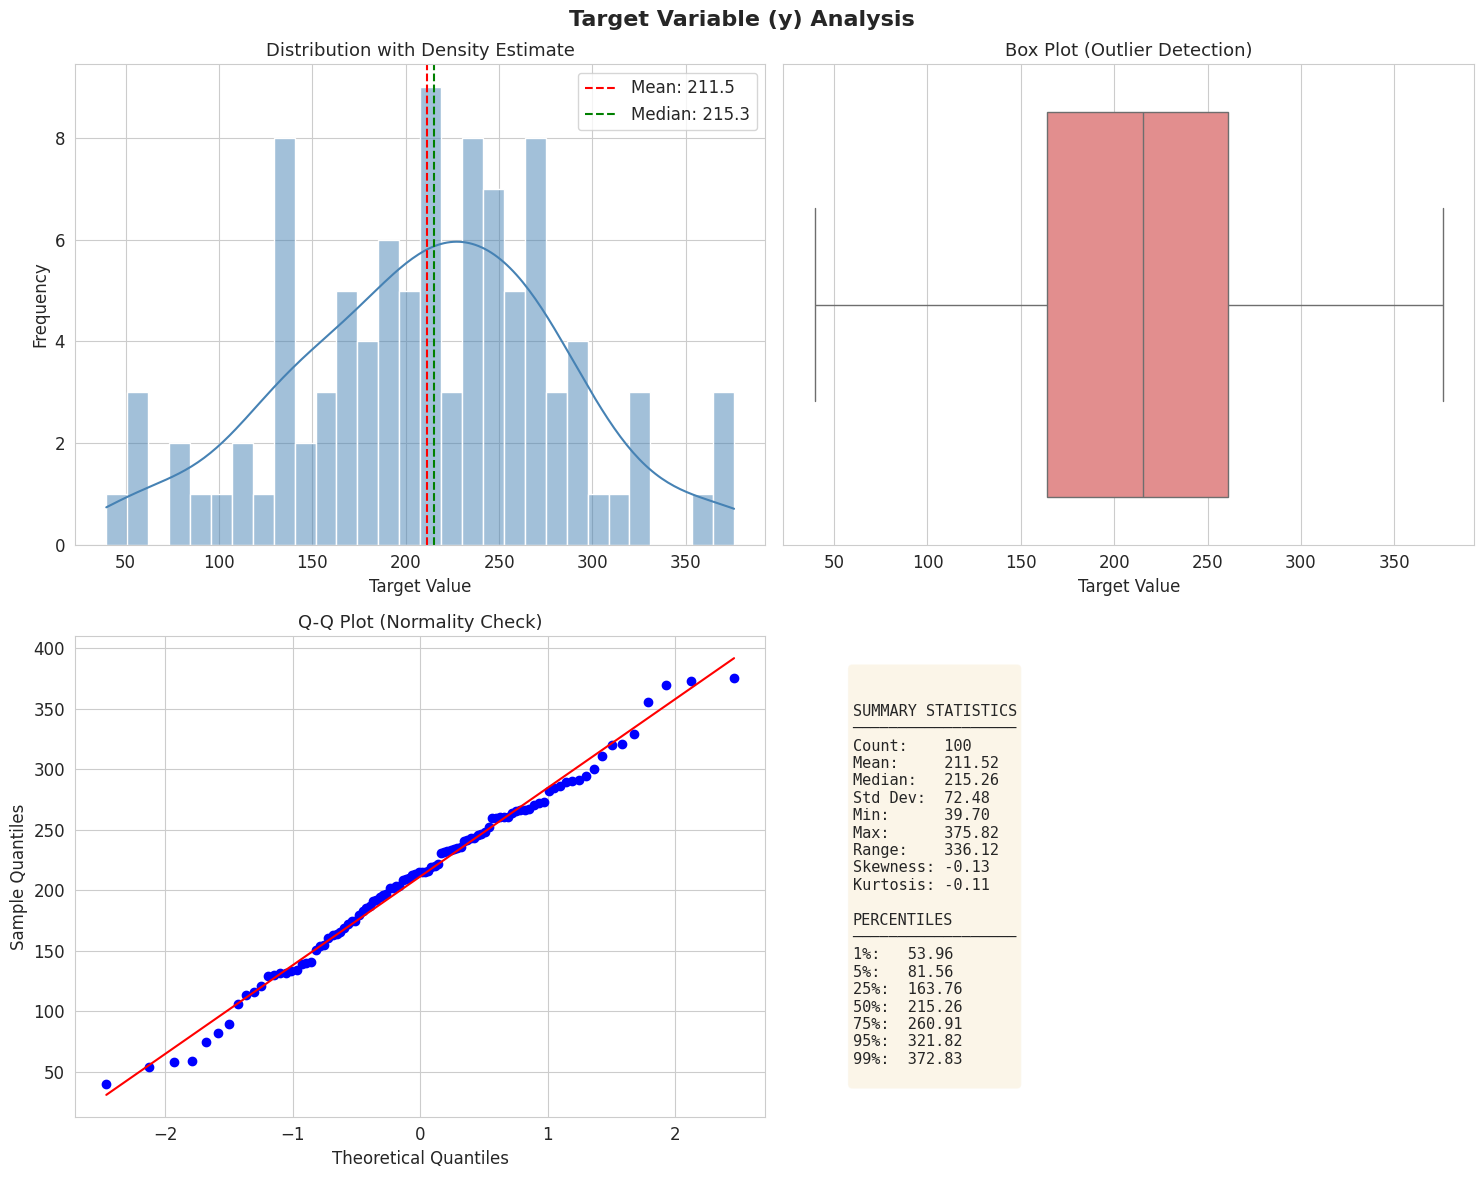

In [7]:
print("\n1. Creating target variable distribution plot...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Target Variable (y) Analysis', fontsize=16, fontweight='bold')

# Histogram with KDE
sns.histplot(y_train, bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution with Density Estimate', fontsize=13)
axes[0, 0].set_xlabel('Target Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(y_train.mean(), color='red', linestyle='--', label=f'Mean: {y_train.mean():.1f}')
axes[0, 0].axvline(y_train.median(), color='green', linestyle='--', label=f'Median: {y_train.median():.1f}')
axes[0, 0].legend()

# Box plot
sns.boxplot(x=y_train, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Box Plot (Outlier Detection)', fontsize=13)
axes[0, 1].set_xlabel('Target Value')

# QQ plot (normality check)
from scipy import stats
stats.probplot(y_train, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=13)
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')

# Summary statistics table
axes[1, 1].axis('off')
stats_text = f"""

SUMMARY STATISTICS
──────────────────
Count:    {len(y_train)}
Mean:     {y_train.mean():.2f}
Median:   {y_train.median():.2f}
Std Dev:  {y_train.std():.2f}
Min:      {y_train.min():.2f}
Max:      {y_train.max():.2f}
Range:    {y_train.max() - y_train.min():.2f}
Skewness: {y_train.skew():.2f}
Kurtosis: {y_train.kurtosis():.2f}

PERCENTILES
──────────────────
1%:   {y_train.quantile(0.01):.2f}
5%:   {y_train.quantile(0.05):.2f}
25%:  {y_train.quantile(0.25):.2f}
50%:  {y_train.quantile(0.50):.2f}
75%:  {y_train.quantile(0.75):.2f}
95%:  {y_train.quantile(0.95):.2f}
99%:  {y_train.quantile(0.99):.2f}
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11,
                verticalalignment='center', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
print(X_new.shape)

(1000, 100)


In [9]:
# Identify categorical columns
cat_cols = [col for col in X_train.columns if col.startswith("C_")]
num_cols = [col for col in X_train.columns if not col.startswith("C_")]

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Number of numerical columns: 95
Number of categorical columns: 5



2. Creating categorical variables visualization...


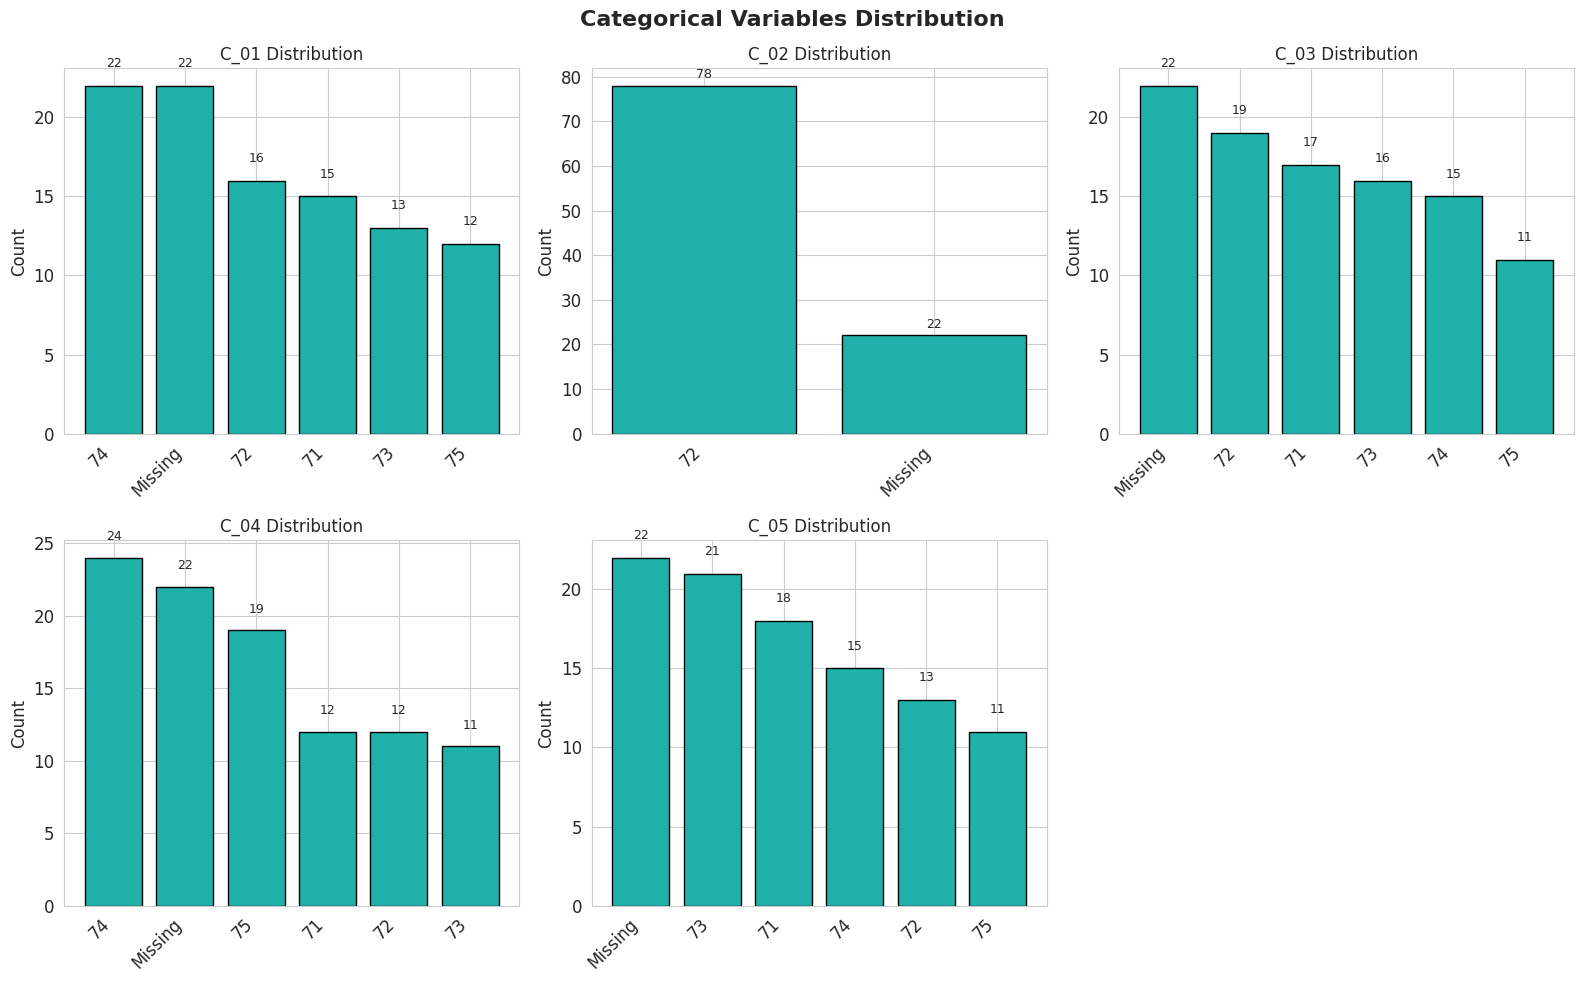

In [10]:
# Categorical variable visualization
print("\n2. Creating categorical variables visualization...")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i < len(axes):
        # Get value counts including NaN
        counts = X_train[col].value_counts(dropna=False)
        # Rename NaN for better display
        counts.index = ['Missing' if pd.isna(x) else f'{int(x)}' for x in counts.index]

        # Create bar plot
        bars = axes[i].bar(range(len(counts)), counts.values, color='lightseagreen', edgecolor='black')
        axes[i].set_xticks(range(len(counts)))
        axes[i].set_xticklabels(counts.index, rotation=45, ha='right')
        axes[i].set_title(f'{col} Distribution', fontsize=12)
        axes[i].set_ylabel('Count')

        # Add value labels
        for bar, val in zip(bars, counts.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        f'{val}', ha='center', va='bottom', fontsize=9)

# Hide unused subplot
if len(cat_cols) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Check missing values
missing_count = X_train.isnull().sum()
missing_percent = (missing_count / len(X_train))*100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False)

print(missing_df[missing_df["Missing Count"] > 0])

      Missing Count  Missing %
x_85             27       27.0
x_12             24       24.0
x_65             22       22.0
C_02             22       22.0
C_01             22       22.0
...             ...        ...
x_89              9        9.0
x_80              9        9.0
x_28              8        8.0
x_61              7        7.0
x_76              6        6.0

[100 rows x 2 columns]



3. Creating missing data visualization...


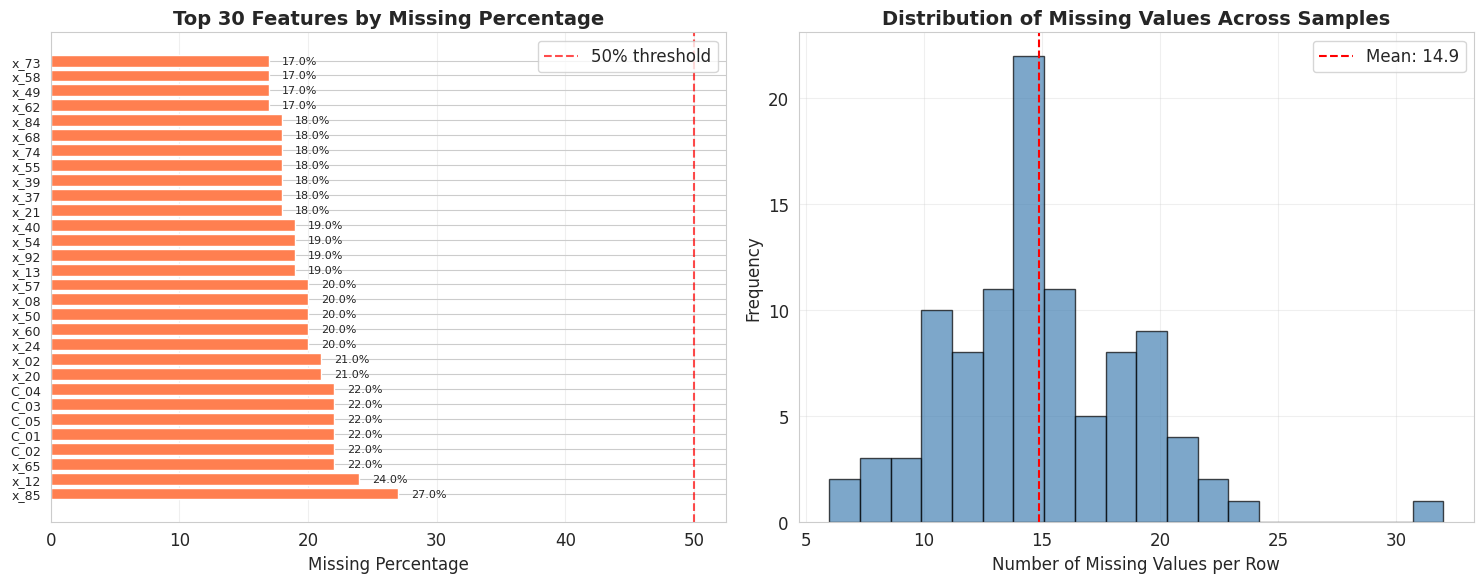

In [12]:
# Missing data pattern visualization
print("\n3. Creating missing data visualization...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Missing by feature
missing_count = X_train.isnull().sum()
missing_percent = (missing_count / len(X_train)) * 100
missing_df = pd.DataFrame({
    'Feature': missing_count.index,
    'Missing %': missing_percent.values
}).sort_values('Missing %', ascending=False).head(30)  # Top 30

ax1 = axes[0]
bars = ax1.barh(range(len(missing_df)), missing_df['Missing %'].values, color='coral')
ax1.set_yticks(range(len(missing_df)))
ax1.set_yticklabels(missing_df['Feature'].values, fontsize=9)
ax1.set_xlabel('Missing Percentage')
ax1.set_title('Top 30 Features by Missing Percentage', fontweight='bold')
ax1.axvline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, missing_df['Missing %'].values)):
    ax1.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8)

# Missing by sample
row_missing = X_train.isnull().sum(axis=1)
ax2 = axes[1]
ax2.hist(row_missing, bins=20, edgecolor='black', color='steelblue', alpha=0.7)
ax2.set_xlabel('Number of Missing Values per Row')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Missing Values Across Samples', fontweight='bold')
ax2.axvline(row_missing.mean(), color='red', linestyle='--',
            label=f'Mean: {row_missing.mean():.1f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('missing_data_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Feature type analysis
binary_cols = [col for col in cat_cols if X_train[col].nunique() == 2]
multi_cols = [col for col in cat_cols if X_train[col].nunique() > 2]

print("Binary categorical features:", len(binary_cols))
print("Multi-category features:", len(multi_cols))


# Positive vs mixed features
positive_only = [col for col in num_cols if (X_train[col] >= 0).all()]
mixed = [col for col in num_cols if not (X_train[col] >= 0).all()]

print("Positive-only features:", len(positive_only))
print("Mixed (+/-) features:", len(mixed))

Binary categorical features: 0
Multi-category features: 4
Positive-only features: 0
Mixed (+/-) features: 95


In [14]:
# Numeric preprocessing (scaled)
numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [15]:
# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [16]:
# Preprocessor for scaled models (Lasso, ridge, elastic net and PCR)
preprocessor_scaled = ColumnTransformer([
    ("num", numeric_scaled, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [17]:
# Preprocessor for random forest (no scaling)
numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_unscaled = ColumnTransformer([
    ("num", numeric_unscaled, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])


4. Creating PCA analysis visualization...


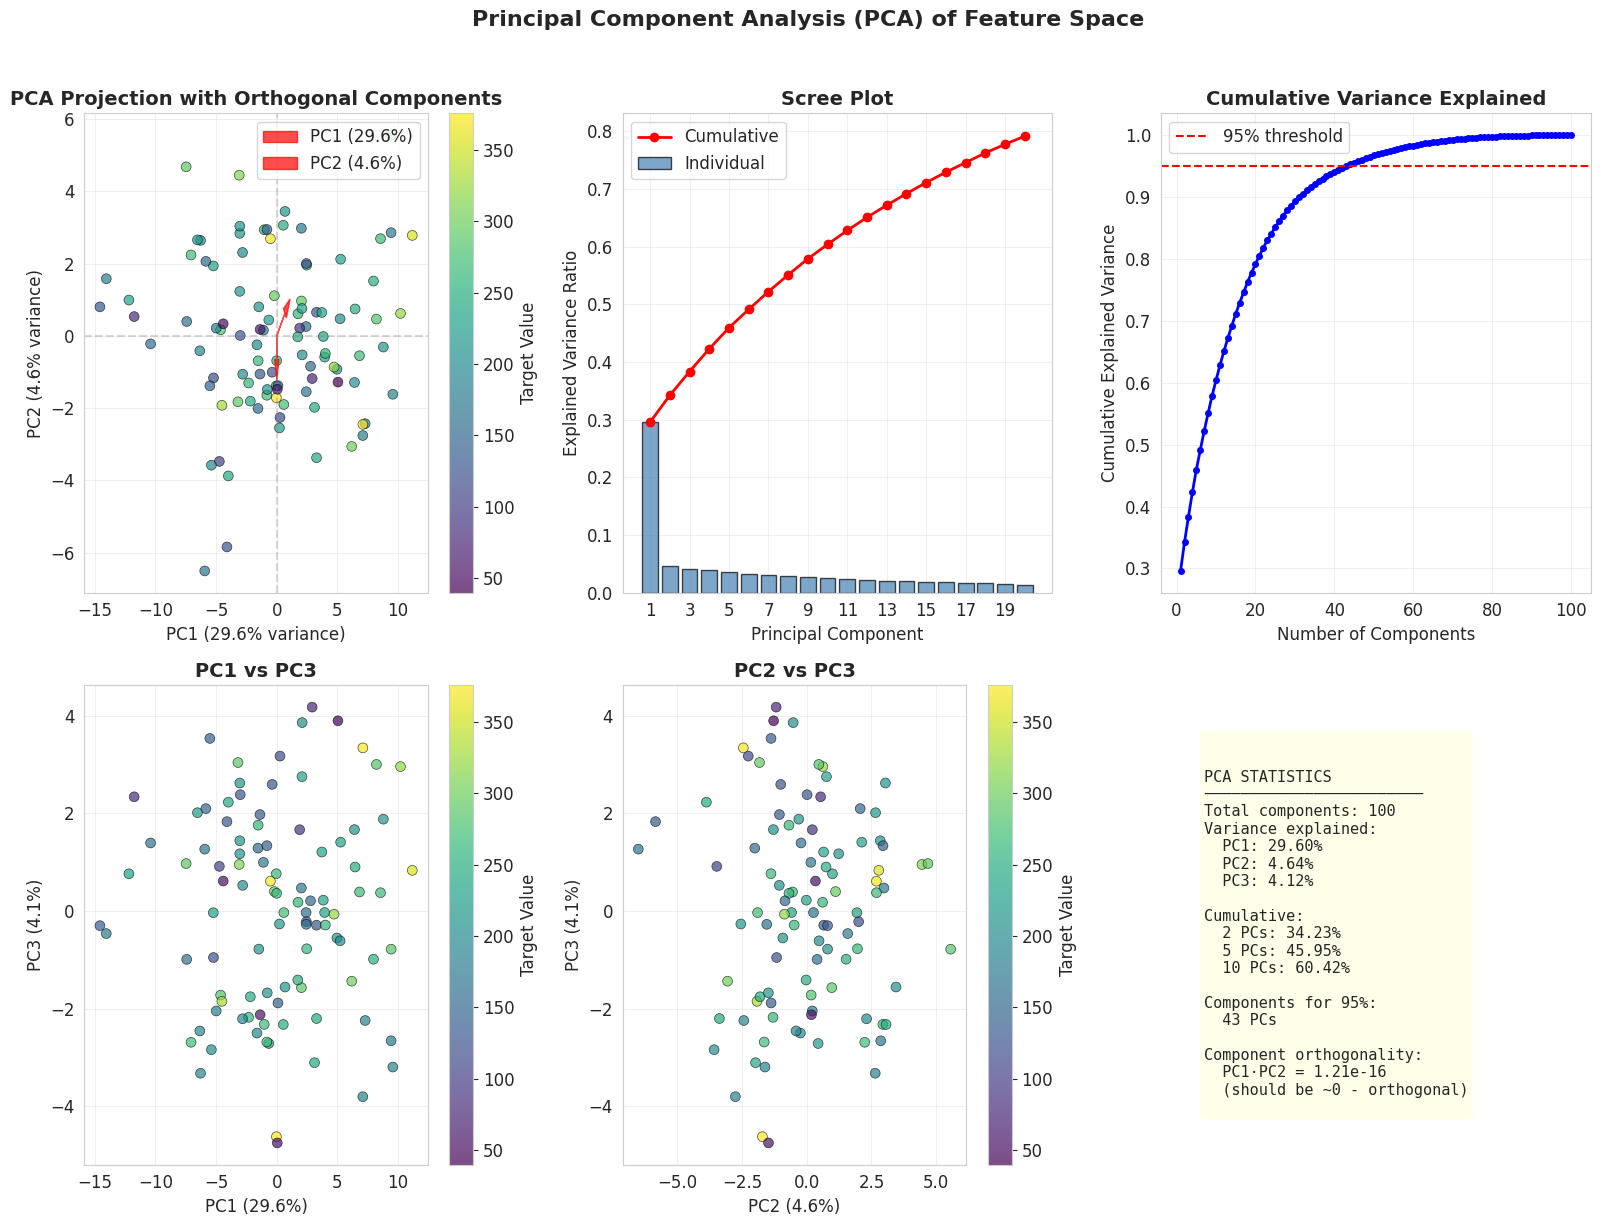

In [18]:
# PCA visualizations
print("\n4. Creating PCA analysis visualization...")

# Preprocess and apply PCA
preprocessor_scaled = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

X_scaled = preprocessor_scaled.fit_transform(X_train)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create comprehensive PCA plot
fig = plt.figure(figsize=(16, 12))

# Plot 1: 2D PCA projection with orthogonal components
ax1 = plt.subplot(2, 3, 1)
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5, s=50)
plt.colorbar(scatter, ax=ax1, label='Target Value')

# Add orthogonal component arrows
scale_factor = np.max(np.abs(X_pca[:, :2])) * 0.8
for i in range(2):
    ax1.arrow(0, 0,
              pca.components_[i, 0] * scale_factor * 0.5,
              pca.components_[i, 1] * scale_factor * 0.5,
              head_width=scale_factor*0.03, head_length=scale_factor*0.05,
              fc='red', ec='red', alpha=0.7,
              label=f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.set_title('PCA Projection with Orthogonal Components', fontweight='bold')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax1.axvline(0, color='gray', linestyle='--', alpha=0.3)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Scree plot
ax2 = plt.subplot(2, 3, 2)
components = np.arange(1, min(21, len(pca.explained_variance_ratio_) + 1))
ax2.bar(components, pca.explained_variance_ratio_[:20],
        alpha=0.7, color='steelblue', edgecolor='black', label='Individual')
ax2.plot(components, np.cumsum(pca.explained_variance_ratio_[:20]),
         'ro-', label='Cumulative', linewidth=2, markersize=6)
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Explained Variance Ratio')
ax2.set_title('Scree Plot', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(components[::2])

# Plot 3: Cumulative variance
ax3 = plt.subplot(2, 3, 3)
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
ax3.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-', linewidth=2, marker='o', markersize=4)
ax3.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax3.set_xlabel('Number of Components')
ax3.set_ylabel('Cumulative Explained Variance')
ax3.set_title('Cumulative Variance Explained', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: PC1 vs PC3
ax4 = plt.subplot(2, 3, 4)
scatter2 = ax4.scatter(X_pca[:, 0], X_pca[:, 2], c=y_train,
                       cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5, s=50)
ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax4.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax4.set_title('PC1 vs PC3', fontweight='bold')
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax4, label='Target Value')

# Plot 5: PC2 vs PC3
ax5 = plt.subplot(2, 3, 5)
scatter3 = ax5.scatter(X_pca[:, 1], X_pca[:, 2], c=y_train,
                       cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5, s=50)
ax5.set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax5.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax5.set_title('PC2 vs PC3', fontweight='bold')
ax5.grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=ax5, label='Target Value')

# Plot 6: PCA statistics
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
pca_text = f"""

PCA STATISTICS
────────────────────────
Total components: {len(pca.explained_variance_ratio_)}
Variance explained:
  PC1: {pca.explained_variance_ratio_[0]:.2%}
  PC2: {pca.explained_variance_ratio_[1]:.2%}
  PC3: {pca.explained_variance_ratio_[2]:.2%}

Cumulative:
  2 PCs: {np.sum(pca.explained_variance_ratio_[:2]):.2%}
  5 PCs: {np.sum(pca.explained_variance_ratio_[:5]):.2%}
  10 PCs: {np.sum(pca.explained_variance_ratio_[:10]):.2%}

Components for 95%:
  {np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1} PCs

Component orthogonality:
  PC1·PC2 = {np.dot(pca.components_[0], pca.components_[1]):.2e}
  (should be ~0 - orthogonal)
"""
ax6.text(0.1, 0.5, pca_text, fontsize=11, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Principal Component Analysis (PCA) of Feature Space', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


5. Creating feature correlation heatmap...
X_scaled shape: (100, 116)
Number of feature names: 121
⚠️ Shape mismatch: X_scaled has 116 columns but feature_names has 121
Using generic column names instead...


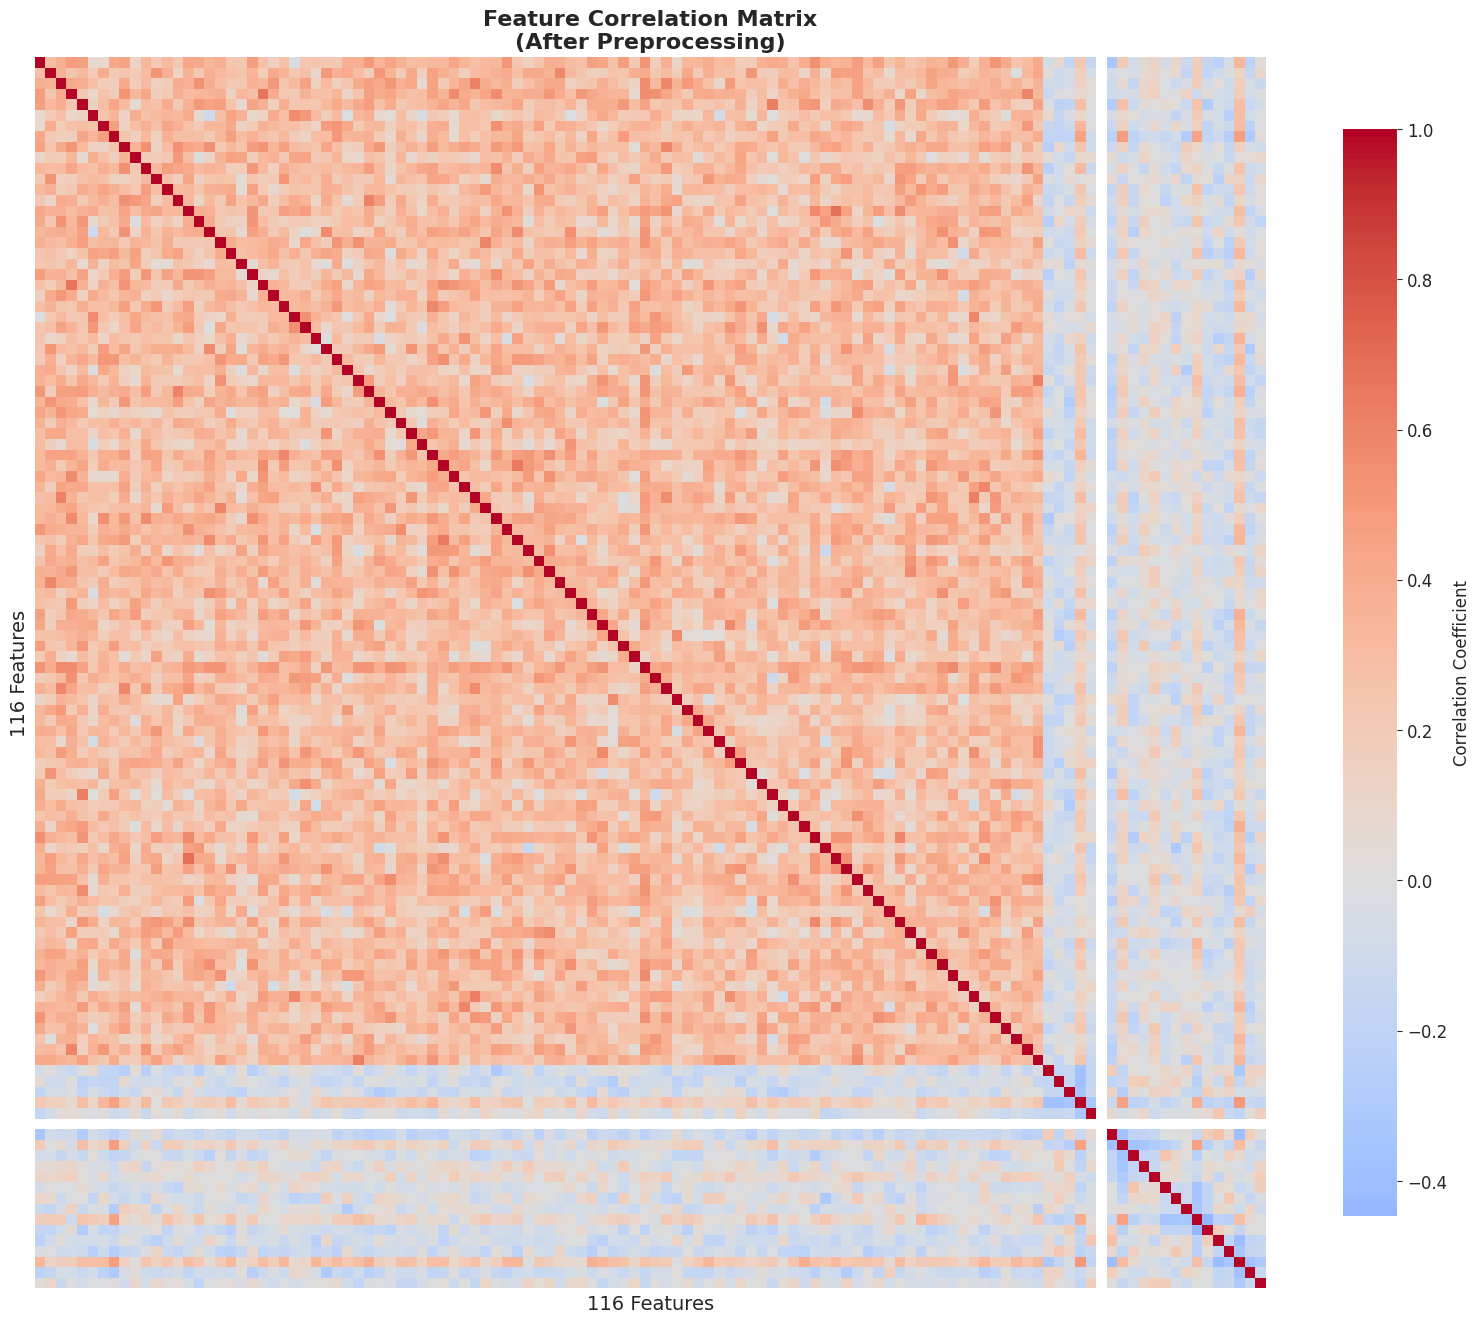

In [20]:
# Visualization
print("\n5. Creating feature correlation heatmap...")

# Get feature names - FIXED VERSION
feature_names = num_cols.copy()

# Get categorical feature names
encoder = preprocessor_scaled.named_transformers_['cat'].named_steps['encoder']
# Don't fit again - it's already fitted when you transformed X_train
cat_feature_names = encoder.get_feature_names_out(cat_cols)
feature_names.extend(cat_feature_names)

# Check shape match
print(f"X_scaled shape: {X_scaled.shape}")
print(f"Number of feature names: {len(feature_names)}")

# Create correlation matrix (only if shapes match)
if X_scaled.shape[1] == len(feature_names):
    corr_matrix = pd.DataFrame(X_scaled, columns=feature_names).corr()

    # Create heatmap
    fig, ax = plt.subplots(figsize=(16, 14))

    # Plot heatmap
    heatmap = sns.heatmap(corr_matrix,
                          cmap='coolwarm',
                          center=0,
                          square=True,
                          cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
                          xticklabels=False,
                          yticklabels=False,
                          ax=ax)

    ax.set_title('Feature Correlation Matrix\n(After Preprocessing)', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'{len(feature_names)} Features', fontsize=14)
    ax.set_ylabel(f'{len(feature_names)} Features', fontsize=14)

    # Add annotation about feature types
    ax.text(0.02, 0.98,
            f'Total features: {len(feature_names)}\nNumeric: {len(num_cols)}\nCategorical (one-hot): {len(cat_feature_names)}',
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            fontsize=12)

    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(f"⚠️ Shape mismatch: X_scaled has {X_scaled.shape[1]} columns but feature_names has {len(feature_names)}")
    print("Using generic column names instead...")

    # Fallback: use generic column names
    corr_matrix = pd.DataFrame(X_scaled).corr()

    fig, ax = plt.subplots(figsize=(16, 14))
    heatmap = sns.heatmap(corr_matrix,
                          cmap='coolwarm',
                          center=0,
                          square=True,
                          cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
                          xticklabels=False,
                          yticklabels=False,
                          ax=ax)
    ax.set_title('Feature Correlation Matrix\n(After Preprocessing)', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'{X_scaled.shape[1]} Features', fontsize=14)
    ax.set_ylabel(f'{X_scaled.shape[1]} Features', fontsize=14)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


6. Creating correlation statistics visualization...


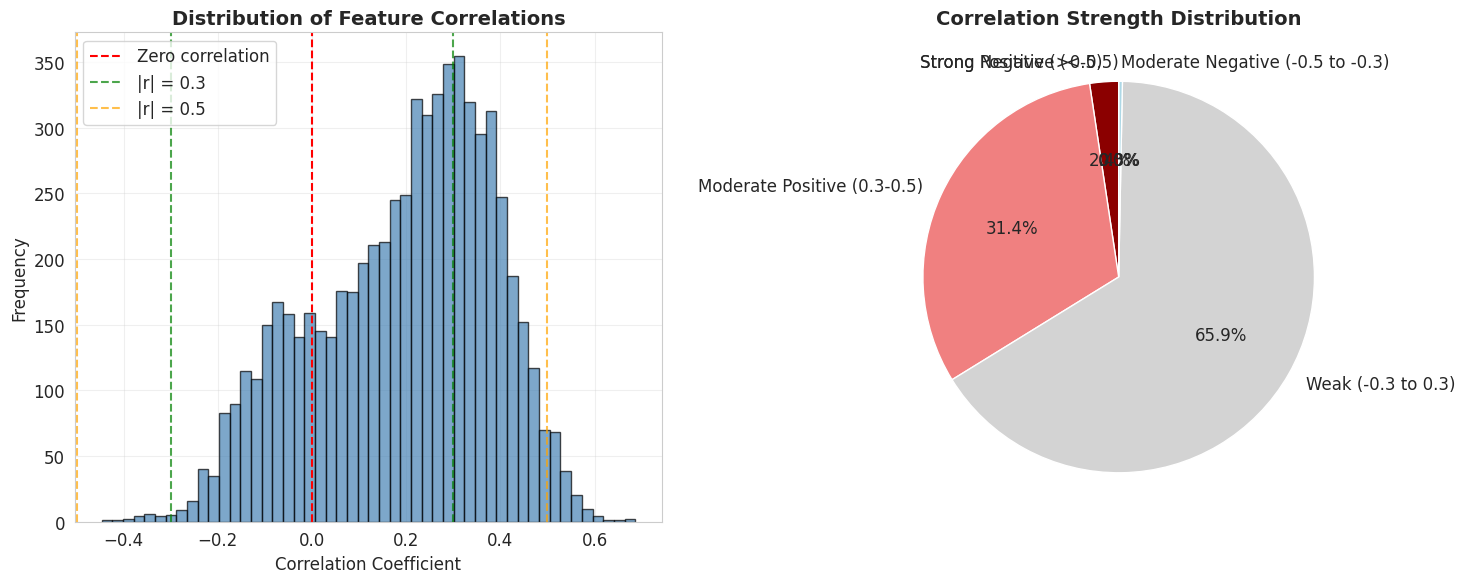

In [21]:
# Correlation statistics visualization
print("\n6. Creating correlation statistics visualization...")

corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of correlations
ax1 = axes[0]
ax1.hist(corr_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(0, color='red', linestyle='--', label='Zero correlation')
ax1.axvline(0.3, color='green', linestyle='--', alpha=0.7, label='|r| = 0.3')
ax1.axvline(-0.3, color='green', linestyle='--', alpha=0.7)
ax1.axvline(0.5, color='orange', linestyle='--', alpha=0.7, label='|r| = 0.5')
ax1.axvline(-0.5, color='orange', linestyle='--', alpha=0.7)
ax1.set_xlabel('Correlation Coefficient')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Feature Correlations', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Correlation categories as pie chart
ax2 = axes[1]
categories = [
    'Strong Positive (>0.5)',
    'Moderate Positive (0.3-0.5)',
    'Weak (-0.3 to 0.3)',
    'Moderate Negative (-0.5 to -0.3)',
    'Strong Negative (<-0.5)'
]
counts = [
    np.sum(corr_values > 0.5),
    np.sum((corr_values > 0.3) & (corr_values <= 0.5)),
    np.sum(np.abs(corr_values) <= 0.3),
    np.sum((corr_values < -0.3) & (corr_values >= -0.5)),
    np.sum(corr_values < -0.5)
]
colors = ['darkred', 'lightcoral', 'lightgray', 'lightblue', 'darkblue']

wedges, texts, autotexts = ax2.pie(counts, labels=categories, colors=colors,
                                     autopct='%1.1f%%', startangle=90)
ax2.set_title('Correlation Strength Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Pipeline creation
def create_model_pipeline(model_name, **params):

    if model_name in ["lasso","ridge","elasticnet","pcr"]:
        preprocessor = preprocessor_scaled
    elif model_name == "randomforest":
        preprocessor = preprocessor_unscaled
    else:
        raise ValueError("Unknown model")

    if model_name == "lasso":
        model = Lasso(**params)

    elif model_name == "ridge":
        model = Ridge(**params)

    elif model_name == "elasticnet":
        model = ElasticNet(**params)

    elif model_name == "randomforest":
        model = RandomForestRegressor(**params)

    elif model_name == "pcr":
        n_components = params.get("n_components",10)

        model = Pipeline([
            ("pca", PCA(n_components=n_components)),
            ("regression", LinearRegression())
        ])

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    return pipeline

In [23]:
# Example pipelines
lasso_pipe = create_model_pipeline("lasso", alpha=1.0)

ridge_pipe = create_model_pipeline("ridge", alpha=1.0)

elastic_pipe = create_model_pipeline("elasticnet", alpha=0.1, l1_ratio=0.5)

rf_pipe = create_model_pipeline("randomforest", n_estimators=100, random_state=42)

pcr_pipe = create_model_pipeline("pcr", n_components=10)

In [24]:
# Rough pipeline test on small sample
X_sample = X_train.head(20)
y_sample = y_train.head(20)

for pipe in [lasso_pipe, ridge_pipe, elastic_pipe, rf_pipe, pcr_pipe]:

    pipe.fit(X_sample, y_sample)

    preds = pipe.predict(X_sample)

    mse = np.mean((y_sample - preds)**2)

    print("Test MSE:", mse)

Test MSE: 14.764108393548502
Test MSE: 0.8694678078210367
Test MSE: 1.367758504092898
Test MSE: 594.2711704149713
Test MSE: 1238.0452096758447
